In [236]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

In [237]:
delivery_df = pd.read_csv('./datasets/delivery_time.csv')

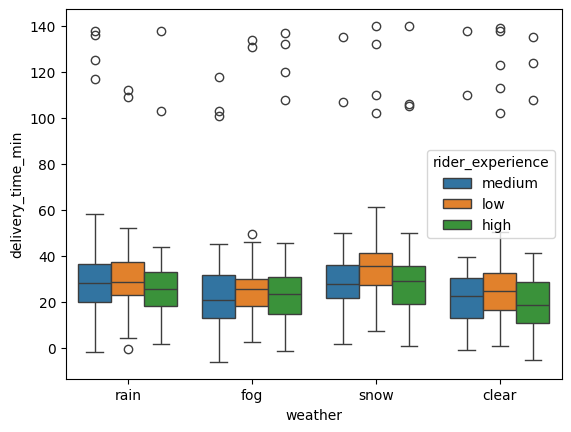

In [238]:
# hue : 데이터를 특정 기준에 따라 색상으로 그룹화(분류)해 주는 역할
sns.boxplot(data=delivery_df, x=delivery_df['weather'], y=delivery_df['delivery_time_min'], hue=delivery_df['rider_experience'])
답03=1

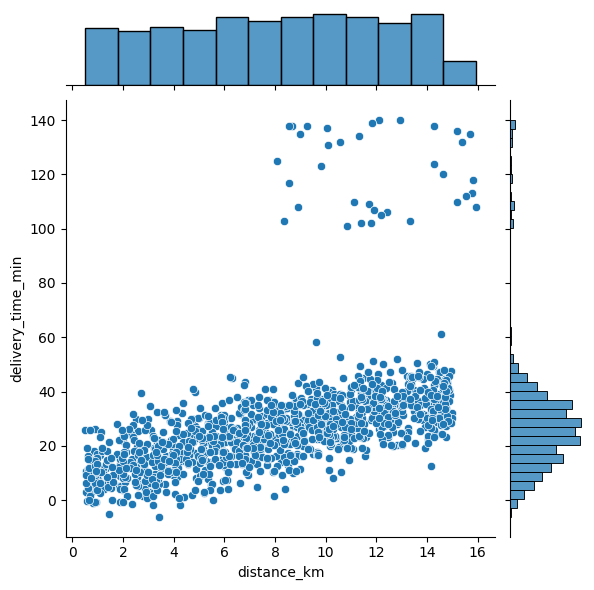

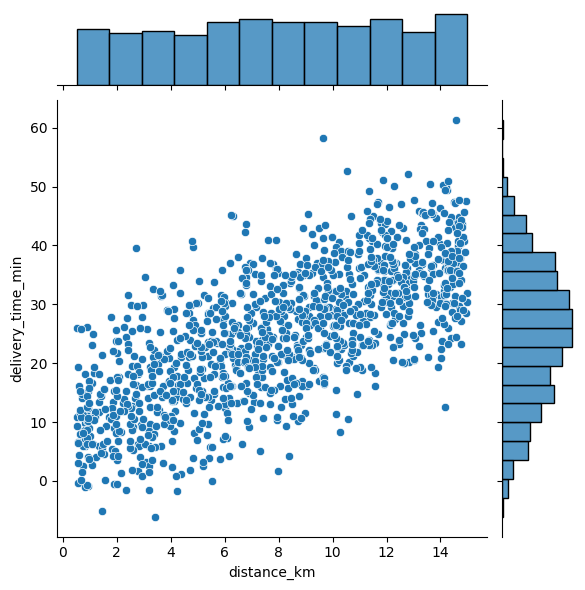

In [239]:
sns.jointplot(data=delivery_df, x=delivery_df['distance_km'], y=delivery_df['delivery_time_min'])
del_df = delivery_df.drop(delivery_df[delivery_df['delivery_time_min']>=100].index, axis=0)
sns.jointplot(data=del_df, x=del_df['distance_km'], y=del_df['delivery_time_min'])

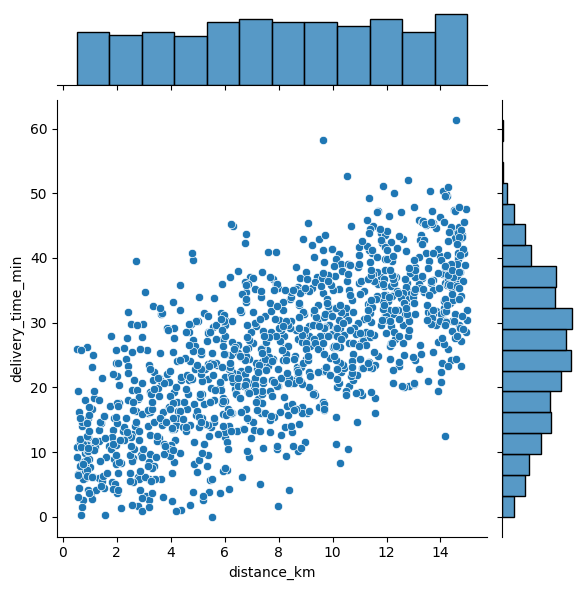

In [240]:
del_df.drop(del_df[del_df['delivery_time_min'] < 0].index, axis=0, inplace=True)
del_df.reset_index(drop=True, inplace=True)
sns.jointplot(data=del_df, x=del_df['distance_km'], y=del_df['delivery_time_min'])

In [241]:
# del_df.drop(columns=['order_amount','num_items'], inplace=True) # 아래와 동일
del_df.drop(['order_amount','num_items'], axis=1, inplace=True)

In [242]:
# 7
cat_col=['rider_experience','weather','order_time']
encoding_df = pd.get_dummies(data=del_df, columns=cat_col, drop_first=True)
encoding_df.head()

,distance_km,promotion_applied,delivery_time_min,rider_experience_low,rider_experience_medium,weather_fog,weather_rain,weather_snow,order_time_evening,order_time_morning,order_time_night
0,6.49,N,26.5,False,True,False,True,False,False,False,False
1,9.17,N,26.4,True,False,True,False,False,False,True,False
2,11.80,Y,37.1,True,False,True,False,False,False,False,True
3,10.67,N,45.0,False,False,False,False,True,True,False,False
4,5.81,Y,20.0,False,False,False,False,True,False,False,True


In [243]:
# 8
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
#encoding_df['promotion_applied'] = encoding_df['promotion_applied'].map({'Y':1,'N':0})
encoding_df['promotion_applied'] = le.fit_transform(encoding_df['promotion_applied'])
encoding_df.head()

,distance_km,promotion_applied,delivery_time_min,rider_experience_low,rider_experience_medium,weather_fog,weather_rain,weather_snow,order_time_evening,order_time_morning,order_time_night
0,6.49,0,26.5,False,True,False,True,False,False,False,False
1,9.17,0,26.4,True,False,True,False,False,False,True,False
2,11.80,1,37.1,True,False,True,False,False,False,False,True
3,10.67,0,45.0,False,False,False,False,True,True,False,False
4,5.81,1,20.0,False,False,False,False,True,False,False,True


In [244]:
# 9
from sklearn.model_selection import train_test_split
X = encoding_df.drop(columns=['delivery_time_min'])
y = encoding_df['delivery_time_min']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)
X_valid

,distance_km,promotion_applied,rider_experience_low,rider_experience_medium,weather_fog,weather_rain,weather_snow,order_time_evening,order_time_morning,order_time_night
767,9.02,0,True,False,False,False,True,False,False,False
461,6.47,0,False,True,True,False,False,False,False,False
787,12.01,1,True,False,False,False,True,False,True,False
593,8.34,1,True,False,True,False,False,False,True,False
388,5.24,1,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
554,7.93,0,False,True,False,True,False,False,False,False
528,5.39,1,True,False,False,False,True,False,False,False
63,4.69,1,True,False,False,False,False,False,True,False
1122,8.18,1,False,False,False,True,False,False,False,False


In [245]:
# 10
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
# fit(): 데이터를 쫙 훑어보고 "평균과 표준편차가 얼마인지 기준(잣대)을 계산해 놔!"
# transform(): 계산된 기준에 맞춰서 "데이터 숫자들을 실제로 변환(이동)시켜!"
# fit_transform(): 기준도 계산하고, 바로 변환까지 "한 방에 처리해!"
X_train = ss.fit_transform(X_train)
X_test = ss.transform(X_valid) # 아까 Train 데이터로 만든 그 기준(잣대)을 그대로 가져와서, Valid 데이터 숫자들을 변환시켜!"라는 뜻
X_train

array([[-0.56478555, -0.79853329, -0.64857316, ...,  1.69527272,
        -0.60993755, -0.55145429],
       [-1.71797432, -0.79853329,  1.54184609, ..., -0.58987559,
        -0.60993755, -0.55145429],
       [-1.6914365 , -0.79853329, -0.64857316, ...,  1.69527272,
        -0.60993755, -0.55145429],
       ...,
       [-0.19566865, -0.79853329,  1.54184609, ...,  1.69527272,
        -0.60993755, -0.55145429],
       [ 0.49190206, -0.79853329, -0.64857316, ...,  1.69527272,
        -0.60993755, -0.55145429],
       [ 0.83448115,  1.25229594, -0.64857316, ..., -0.58987559,
        -0.60993755, -0.55145429]], shape=(922, 10))

In [246]:
# 11
from sklearn.linear_model import LinearRegression
from sklearn import set_config

# 모델 출력을 HTML이 아닌 일반 텍스트 모드로 변경
set_config(display='text')
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [247]:
# 12
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rfr.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [248]:
# 13
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, BatchNormalization
tf.random.set_seed(42)

model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization()) # 데이터가 층을 통과할 때마다 값이 너무 커지거나 작아지지 않게 중간중간 다시 정돈(스케일링)해 주는 기술입니다. 학습 속도와 성능을 크게 높여줍니다
model.add(Dense(32, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))

# 만들어진 신경망에게 "어떻게 공부할지" 룰을 정해줍니다.
# optimizer='adam': 정답을 찾아가는 똑똑한 내비게이션(최적화 알고리즘)입니다. 보통 adam을 가장 많이 씁니다.
# loss='mean_squared_error': 모델이 얼마나 틀렸는지 채점하는 기준(오차)입니다. 회귀 문제이므로 MSE를 사용합니다.
# metrics: 사람이 보기 편한 보조 채점 지표로 MAE(절대 오차)를 추가로 확인하겠다는 뜻입니다.
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

# epochs=50: 준비된 문제집(X_train)을 처음부터 끝까지 총 50번 반복해서 풀어라는 뜻입니다.
# batch_size=128: 문제집을 풀 때 1번 문제부터 128번 문제까지 푼 다음, 정답을 맞춰보고 오답 노트를 작성(가중치 업데이트)하라는 뜻입니다.
# validation_data: 한 번의 epoch(1회독)이 끝날 때마다 모의고사를 쳐서 실력이 진짜 오르고 있는지 스스로 평가하라는 의미입니다.
model.fit(X_train, y_train, epochs=50, batch_size=128, validation_data=(X_test, y_valid))



Epoch 1/50


c:\Users\zzina\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 776.6415 - mean_absolute_error: 25.5952 - val_loss: 756.8910 - val_mean_absolute_error: 25.1386
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 749.9111 - mean_absolute_error: 25.1563 - val_loss: 748.1104 - val_mean_absolute_error: 24.9886
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 728.1581 - mean_absolute_error: 24.7806 - val_loss: 739.1351 - val_mean_absolute_error: 24.8345
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 708.3289 - mean_absolute_error: 24.4294 - val_loss: 729.3813 - val_mean_absolute_error: 24.6668
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 688.7645 - mean_absolute_error: 24.0740 - val_loss: 718.4184 - val_mean_absolute_error: 24.4794
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 668.7101 - mean_absolute_error: 23.7044 - val_loss: 706.1075 - val_mean_absolute_error: 24.2685
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 647.7861 - mean_absolute_error: 23.3168 -

In [ ]:
# 14
# 딥러닝 모델이 학습을 하는 동안 옆에서 똑똑하게 보조해 주는 '콜백(Callbacks)' 기능입니다. AICE 시험의 딥러닝 파트에서 무조건 출제되는 가장 핵심적인 과적합(Overfitting) 방지 기술
from keras.callbacks import EarlyStopping, ModelCheckpoint # '조기 종료(EarlyStopping)' 기능과 '자동 저장(ModelCheckpoint)' 기능
# 의미: 쓸데없는 시간 낭비와 과적합을 막기 위해 "성적이 안 오르면 학습을 일찍 끝내라"고 타이머를 맞추는 설정입니다.
# monitor='val_loss': 무엇을 보고 판단할지 정합니다. 모의고사 오답률(검증 데이터의 오차)을 기준으로 삼습니다.
# patience=5 ⭐️(시험 단골): 성적이 안 올라도 '몇 번(Epoch)까지 참고 기다려 줄 것인가'입니다. 5번 연속으로 오답률이 줄어들지(개선되지) 않으면 가차 없이 학습을 중단시킵니다.
# restore_best_weights=True ⭐️(가장 중요): 학습이 강제로 종료되었을 때, 종료된 시점의 멍청해진 뇌(가중치) 상태를 유지할 것인지 묻는 옵션입니다. True로 설정하면 "가장 성적이 좋았던 그 황금기 시점으로 뇌 상태를 되돌려라"라는 뜻이 됩니다.
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 의미: 학습하는 중간중간 가장 똑똑했던 순간을 파일로 자동 저장하는 설정입니다. (게임에서 보스방 들어가기 전 세이브포인트를 만드는 것과 같습니다.)
# 'best_model.h5': 저장할 파일의 이름과 확장자입니다.
# save_best_only=True: 매번 저장하면 용량이 꽉 차니까, "이전 기록을 갱신(최고점 달성)했을 때만 덮어씌워서 저장해라"라는 뜻입니다.
# verbose=1: 모델이 저장될 때마다 화면에 "모델이 저장되었습니다"라는 로그 메시지를 띄워달라는 의미입니다.
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, verbose=1)

model.fit(X_train, y_train, epochs=50, batch_size=128, validation_data=(X_test, y_valid), callbacks=[early_stopping, model_checkpoint])

Epoch 1/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 50.3939 - mean_absolute_error: 5.9088
Epoch 1: val_loss improved from None to 67.81154, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 50.2758 - mean_absolute_error: 5.6204 - val_loss: 67.8115 - val_mean_absolute_error: 6.6012
Epoch 2/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 49.6620 - mean_absolute_error: 5.8764
Epoch 2: val_loss improved from 67.81154 to 66.78410, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 49.2738 - mean_absolute_error: 5.5642 - val_loss: 66.7841 - val_mean_absolute_error: 6.5489
Epoch 3/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 49.0125 - mean_absolute_error: 5.8489
Epoch 3: val_loss improved from 66.78410 to 65.84856, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 48.3312 - mean_absolute_error: 5.5129 - val_loss: 65.8486 - val_mean_absolute_error: 6.4975
Epoch 4/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 48.3582 - mean_absolute_error: 5.8132
Epoch 4: val_loss improved from 65.84856 to 65.10133, saving model to best_model.h5



Epoch 4: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 47.4215 - mean_absolute_error: 5.4617 - val_loss: 65.1013 - val_mean_absolute_error: 6.4522
Epoch 5/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 47.9081 - mean_absolute_error: 5.7845
Epoch 5: val_loss improved from 65.10133 to 64.35023, saving model to best_model.h5


...


Epoch 21: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 36.9259 - mean_absolute_error: 4.8469 - val_loss: 59.1071 - val_mean_absolute_error: 6.0645
Epoch 22/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 38.2421 - mean_absolute_error: 5.2090
Epoch 22: val_loss improved from 59.10709 to 58.99847, saving model to best_model.h5



Epoch 22: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 36.4905 - mean_absolute_error: 4.8187 - val_loss: 58.9985 - val_mean_absolute_error: 6.0555
Epoch 23/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 37.8054 - mean_absolute_error: 5.1757
Epoch 23: val_loss improved from 58.99847 to 58.92392, saving model to best_model.h5



Epoch 23: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 36.0723 - mean_absolute_error: 4.7917 - val_loss: 58.9239 - val_mean_absolute_error: 6.0533
Epoch 24/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 37.5474 - mean_absolute_error: 5.1515
Epoch 24: val_loss improved from 58.92392 to 58.82243, saving model to best_model.h5



Epoch 24: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 35.6767 - mean_absolute_error: 4.7663 - val_loss: 58.8224 - val_mean_absolute_error: 6.0538
Epoch 25/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 37.1992 - mean_absolute_error: 5.1122
Epoch 25: val_loss did not improve from 58.82243
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 35.3259 - mean_absolute_error: 4.7399 - val_loss: 58.8330 - val_mean_absolute_error: 6.0536
Epoch 26/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 36.8577 - mean_absolute_error: 5.0826
Epoch 26: val_loss did not improve from 58.82243
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 35.0155 - mean_absolute_error: 4.7193 - val_loss: 58.8665 - val_mean_absolute_error: 6.0572
Epoch 27/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 36.5887 - mean_absolute_error: 5.0581
Epoch 27: val_loss did not improve from 58.82243
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 34.6971 - mean_absolute_error: 4.7000 - val_loss: 58.8385 


Epoch 28: finished saving model to best_model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 34.4116 - mean_absolute_error: 4.6809 - val_loss: 58.7809 - val_mean_absolute_error: 6.0581
Epoch 29/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 36.1201 - mean_absolute_error: 5.0230
Epoch 29: val_loss did not improve from 58.78085
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 34.1143 - mean_absolute_error: 4.6610 - val_loss: 58.8100 - val_mean_absolute_error: 6.0605
Epoch 30/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 35.9364 - mean_absolute_error: 5.0100
Epoch 30: val_loss did not improve from 58.78085
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 33.8322 - mean_absolute_error: 4.6395 - val_loss: 58.9512 - val_mean_absolute_error: 6.0702
Epoch 31/50
1/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 35.6546 - mean_absolute_error: 4.9882
Epoch 31: val_loss did not improve from 58.78085
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 33.5748 - mean_absolute_error: 4.6225 - val_loss: 59.0283